In [2]:
# Credit Score Classification Project
# Objective: Analyze demographic and financial data to classify credit scores (Good, Standard, Poor) and find actionable insights into credit risk factors.

In [3]:
# 1. Fetching and Reading Data
# In this section, we initialize the environment, import necessary libraries, and load the dataset. We perform an initial inspection to understand the data structure, types, and volume.

In [18]:
# Import all libraries

!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install category_encoders

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded!")

Libraries loaded!


In [19]:
# Load data, if it exists
# Specify low_memory=False to avoid mixed types error (will cover later in preprocessing)

try:
    train_df = pd.read_csv('Credit_Score_Data.csv', low_memory=False)
    print("All files successfully loaded!")
except FileNotFoundError as e:
    print("Error loading files. Please ensure the dataset is in the same directory as this Jupyter file.")

All files successfully loaded!


In [20]:
# Ignore FutureWarnings (they pop up in some of our sns graphs)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [21]:
# Exploratory Data Analysis (EDA)

# Head of the data
print("Head of the data: ")
display(train_df.head())
print("\n")

# Shape of the data
print(f"The training data has {train_df.shape[0]} rows and {train_df.shape[1]} columns")
print(f"The test data has {test_df.shape[0]} rows and {test_df.shape[1]} columns (missing Credit_Score target variable)")
print("\n")

# Basic information about the structure and dtypes of the data
print("Data structure and types: ")
train_df.info()
print("\n")

# Check to see which columns have nulls
print("Columns with missing values: ")
print(train_df.isnull().sum()[train_df.isnull().sum()>0].sort_values(ascending=False))
print("\n")

# Check for duplicate rows
print(f"Number of duplicate rows: {train_df.duplicated().sum()}")

Head of the data: 


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good




The training data has 100000 rows and 28 columns
The test data has 50000 rows and 27 columns (missing Credit_Score target variable)


Data structure and types: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  

In [8]:
# 2. Data Exploration (EDA)
# In this section, we explore the dataset to identify distributions, relationships, and potential quality issues.

# NOTE: Here we'll focus primarily on the numerical columns (e.g., Interest Rate, Number of Bank Accounts) and categorical variables. Columns requiring heavy cleaning will be analyzed in depth after Preprocessing is finished.

Distribution of credit score (%): 
Credit_Score
Standard    53.174
Poor        28.998
Good        17.828
Name: count, dtype: float64




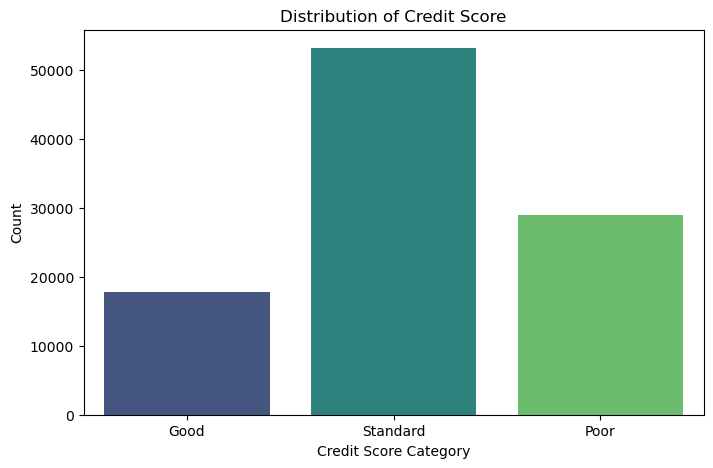



The target variable is imbalanced. 'Standard' is the majority class (~53%), while 'Good' is the minority (~17%)
This makes sense, given the generally normal distribution of credit scores


In [6]:
# Analysis of Credit_Score target variable

# Visualize the distribution of credit score categories
# Calculate and print normalized percentages
print("Distribution of credit score (%): ")
counts = train_df['Credit_Score'].value_counts()
percentages = (counts/(counts.sum()))*100
print(percentages)
print("\n")

# Create a countplot of Credit Score count
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='Credit_Score', order=['Good', 'Standard', 'Poor'], palette='viridis')
plt.title('Distribution of Credit Score')
plt.ylabel('Count')
plt.xlabel('Credit Score Category')
plt.show()
print("\n")

# Insights
print("The target variable is imbalanced. 'Standard' is the majority class (~53%), while 'Good' is the minority (~17%)")
print("This makes sense, given the generally normal distribution of credit scores")

All numerical columns: 

Monthly_Inhand_Salary
Num_Bank_Accounts
Num_Credit_Card
Interest_Rate
Delay_from_due_date
Num_Credit_Inquiries
Credit_Utilization_Ratio
Total_EMI_per_month


Descriptive statistics of each column: 


,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


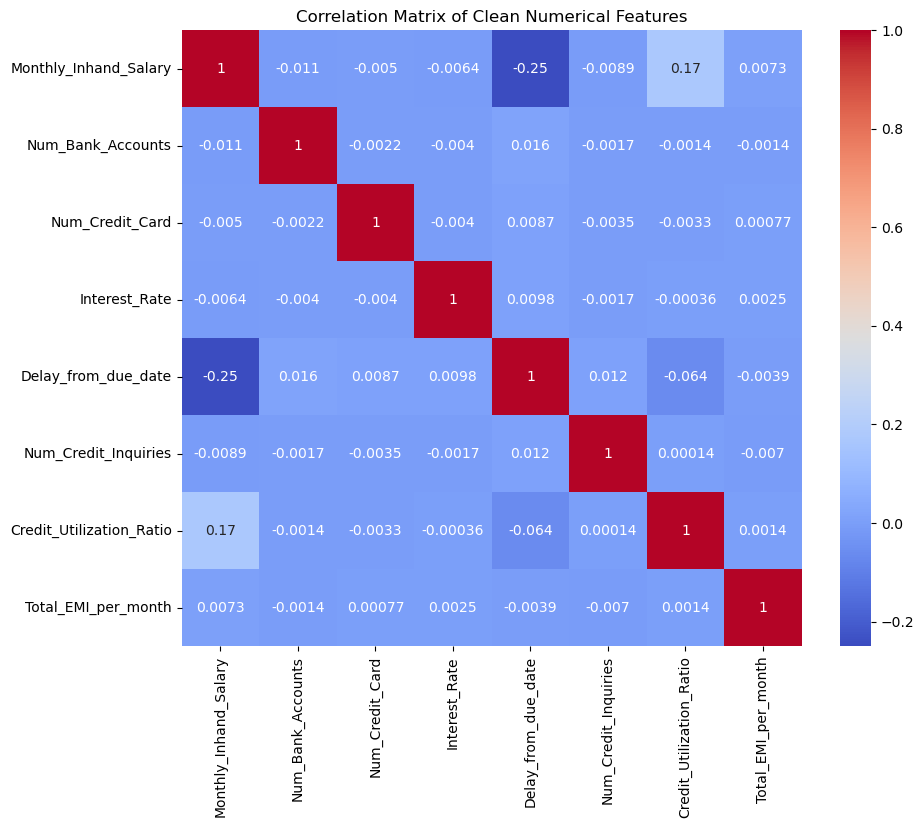



Most variables have weak linear correlations with one another.
Monthly salary has a slight negative corr with average payment delayment, monthly salary also has a slight positive corr with credit utilization ratio.


In [7]:
# Analysis of correlation of (clean) numerical features

# Isolate and print columns that are already numeric and don't require heavy cleaning yet
clean_numericals = [i for i in train_df.columns if (train_df[i].dtype != 'object')]
print("All numerical columns: \n")
for i in train_df[clean_numericals].columns:
    print(i)
print("\n")

# Explore descriptive stats of all numeric cols
print("Descriptive statistics of each column: ")
display(train_df[clean_numericals].describe())
print("\n")

# Create a corr matrix to check for multicollinearity among these variables
plt.figure(figsize=(10, 8))
corr_matrix = train_df[clean_numericals].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Clean Numerical Features')
plt.show()
print("\n")

# Insights
print("Most variables have weak linear correlations with one another.")
print("Monthly salary has a slight negative corr with average payment delayment, monthly salary also has a slight positive corr with credit utilization ratio.")

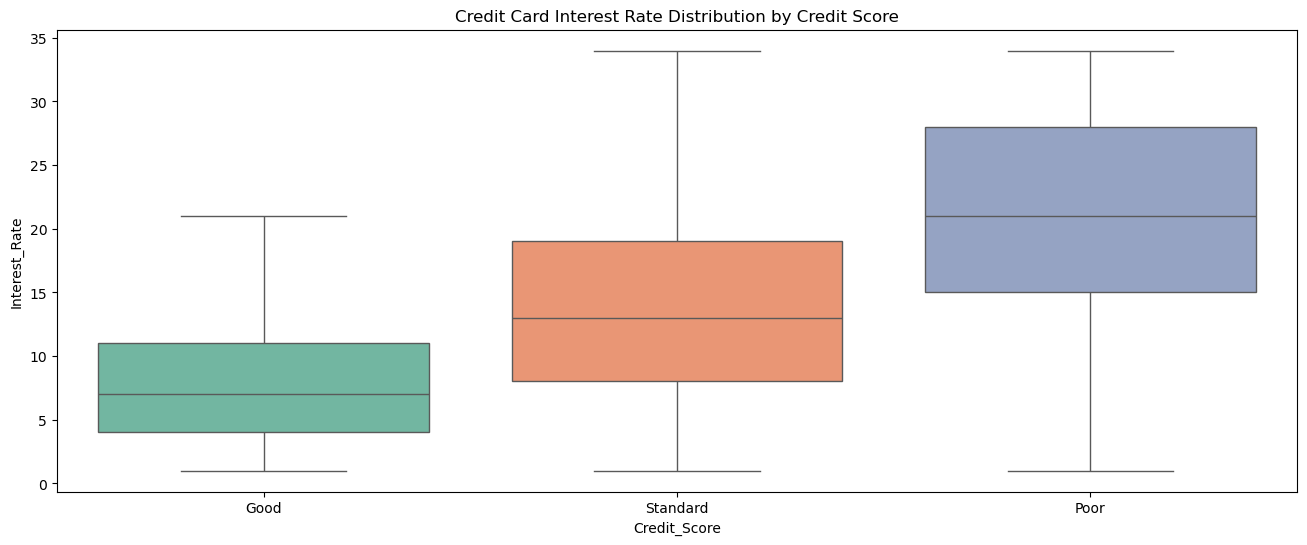

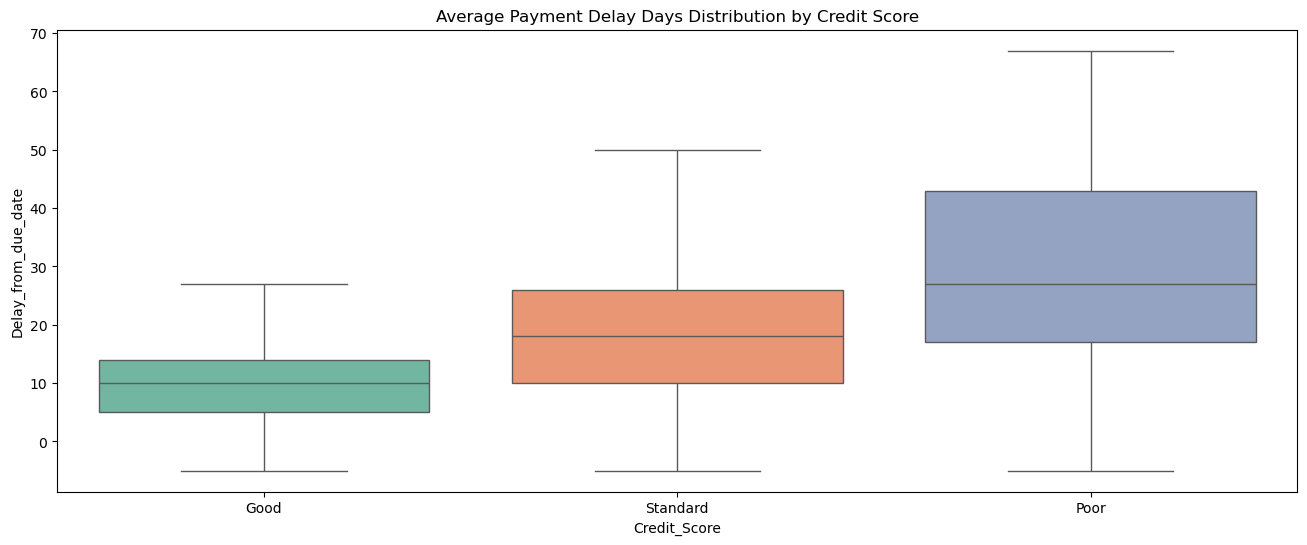



Mean values by Credit Score category


,Interest_Rate,Delay_from_due_date
Credit_Score,,
Good,73.958717,10.892753
Poor,76.196772,29.744051
Standard,69.931057,19.749577




In most cases, average credit card interest rate and payment delay date increases as credit score decreases.
The only exception is mean of interest rate being lower for Standard than Good credit score.


In [8]:
# Analysis of how different variables relate to the target variable

# Create boxplots to see if 'Interest_Rate' or 'Delay_from_due_date' affects Credit Score.

# Create a boxplot for 'interest rate'
plt.figure(figsize=(16, 6))
sns.boxplot(data=train_df, x='Credit_Score', y='Interest_Rate', order=['Good', 'Standard', 'Poor'], palette='Set2', showfliers=False)
plt.title('Credit Card Interest Rate Distribution by Credit Score')
plt.show()
print("\n")

# Create a boxplot for 'delay from due date'
plt.figure(figsize=(16, 6))
sns.boxplot(data=train_df, x='Credit_Score', y='Delay_from_due_date', order=['Good', 'Standard', 'Poor'], palette='Set2', showfliers=False)
plt.title('Average Payment Delay Days Distribution by Credit Score')
plt.show()
print("\n")

# Grouped aggregation to identify means
print("Mean values by Credit Score category")
display(train_df.groupby('Credit_Score')[['Interest_Rate','Delay_from_due_date']].mean())
print("\n")

# Insights
print("In most cases, average credit card interest rate and payment delay date increases as credit score decreases.")
print("The only exception is mean of interest rate being lower for Standard than Good credit score.")

Percentage of missing data per column: 
Monthly_Inhand_Salary      15.002
Type_of_Loan               11.408
Name                        9.985
Credit_History_Age          9.030
Num_of_Delayed_Payment      7.002
Amount_invested_monthly     4.479
Num_Credit_Inquiries        1.965
Monthly_Balance             1.200
dtype: float64




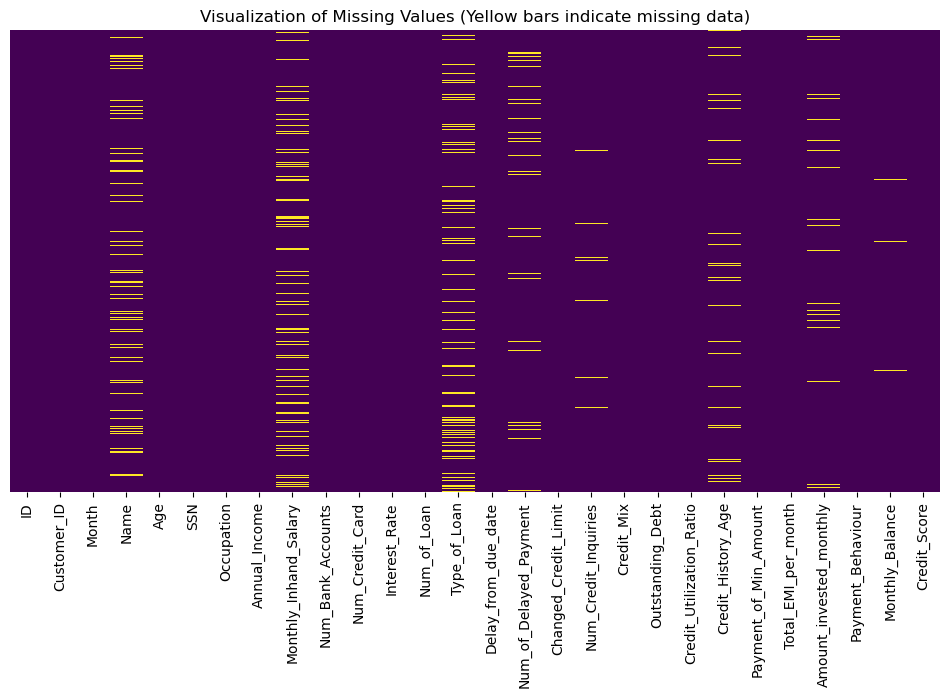



It's clear that a lot of the data needs cleaning.
This justifies the need for the pre-processing section right after.


In [9]:
# Visualizing potential issues in data quality

# Quantification of missing values
missing_percent = ((train_df.isnull().sum())/len(train_df))*100
print("Percentage of missing data per column: ")
print(missing_percent[missing_percent>0].sort_values(ascending=False))
print("\n")

# Heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Visualization of Missing Values (Yellow bars indicate missing data)')
plt.show()
print("\n")

# Insights
print("It's clear that a lot of the data needs cleaning.")
print("This justifies the need for the pre-processing section right after.")

In [13]:
# 3. Data Cleaning and Preprocessing
# In this section, we clean and process the data to ensure it is ready for visualization and predictive analysis.

In [22]:
# Create a copy to avoid SettingWithCopy warning
df_clean = train_df.copy()

# Drop the ID, Name, SSN and Month cols as otherwise they'll cause overfitting
cols_dropped = ['ID','Customer_ID','Name','SSN','Month']
df_clean.drop(columns=cols_dropped, inplace=True)

# Print dropped columns
print("Dropped columns: ")
for i in cols_dropped:
    print(i)

Dropped columns: 
ID
Customer_ID
Name
SSN
Month


In [23]:
# Clean NUMERIC columns and convert to correct dtype

# Use str.replace() to clean text of bad chars and pd.to_numeric() to convert cols from 'object' dtype to numeric dtype
# Then use .loc[] to remove all negative values per col

cols_to_clean = ['Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date','Changed_Credit_Limit','Num_of_Delayed_Payment','Outstanding_Debt','Amount_invested_monthly', 'Monthly_Balance']

for i in cols_to_clean:
    df_clean[i] = (df_clean[i].astype(str).str.replace('_', '', regex=False).pipe(pd.to_numeric, errors='coerce'))
    df_clean.loc[df_clean[i]<= 0, i] = np.nan

df_clean.head(3)

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,23.0,Scientist,19114.12,NaN,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,...,Good,809.98,31.944960,NaN,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,NaN,Scientist,19114.12,NaN,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good


In [24]:
# Clean lingering garbage values in CATEGORICAL columns

df_clean['Payment_Behaviour'] = (df_clean['Payment_Behaviour'].astype(str).str.replace('[^A-Za-z_]', '', regex=True).replace('', np.nan))
df_clean['Payment_of_Min_Amount'] = df_clean['Payment_of_Min_Amount'].replace('NM', np.nan)
df_clean['Credit_Mix'] = df_clean['Credit_Mix'].replace('_', np.nan)
df_clean['Occupation'] = df_clean['Occupation'].replace('_______', np.nan)

df_clean.head(3)

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,...,NaN,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,23.0,Scientist,19114.12,NaN,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,...,Good,809.98,31.944960,NaN,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,NaN,Scientist,19114.12,NaN,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good


In [25]:
# Feature engineering credit history age
# Instead of years and months, let's turn it into a numeric column of months

# Extract the numbers using regex pattern, (\d+) means "find digits"
years = df_clean['Credit_History_Age'].str.extract(r'(\d+) Years').astype(float)
months = df_clean['Credit_History_Age'].str.extract(r'(\d+) Months').astype(float)

# Calculate total months and drop the original since we don't need it anymore
df_clean['Credit_History_Age_Months'] = ((years[0]*12) + months[0])
df_clean = df_clean.drop(columns=['Credit_History_Age'])

df_clean['Credit_History_Age_Months'].head()

0    265.0
1      NaN
2    267.0
3    268.0
4    269.0
Name: Credit_History_Age_Months, dtype: float64

In [27]:
# Feature engineering payment behavior and type of loan
# For 'Type_of_Loan', we want to split the text into categories of loans, for better interpretability

# Clean column to prepare it for processing
df_clean['Type_of_Loan'] = df_clean['Type_of_Loan'].astype(str).str.replace('and ', '').str.replace(', ', ',')

# For each loan type, perform one-hot encoding
loan_types = ['Auto Loan','Credit-Builder Loan','Personal Loan','Home Equity Loan','Mortgage Loan','Student Loan','Payday Loan','Debt Consolidation Loan', 'Not Specified']
for i in loan_types:
    # Create a new binary column: 1 if the customer has this loan, 0 if not
    name = f'Has_{i.replace(" ", "_")}'
    df_clean[name] = df_clean['Type_of_Loan'].str.contains(i, case=False, regex=False).astype(int)

# For 'Payment_Behavior', we want to split based on spending level (high or low) and value of payment (small, medium, or large)

# Encode spending level column
df_clean['Spending_Level_Encoded'] = df_clean['Payment_Behaviour'].apply(lambda i: 1 if 'High_spent' in str(i) else 0)

# Encode value size column
# Using numpy vectorized operations to encode on patterns in text
df_clean['Value_Size_Encoded'] = np.select([
    df_clean['Payment_Behaviour'].str.contains('Small_value', na=False),
    df_clean['Payment_Behaviour'].str.contains('Medium_value', na=False),
    df_clean['Payment_Behaviour'].str.contains('Large_value', na=False),],
    [0, 1, 2],default=1)

# Fix to make sure all NaNs carry over
df_clean.loc[df_clean['Payment_Behaviour'].isna(), 'Value_Size_Encoded'] = np.nan

# Drop original columns
df_clean.drop(columns=['Type_of_Loan', 'Payment_Behaviour'], inplace=True)
df_clean.head(3)

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Has_Credit-Builder_Loan,Has_Personal_Loan,Has_Home_Equity_Loan,Has_Mortgage_Loan,Has_Student_Loan,Has_Payday_Loan,Has_Debt_Consolidation_Loan,Has_Not_Specified,Spending_Level_Encoded,Value_Size_Encoded
0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,...,1,1,1,0,0,0,0,0,1,0.0
1,23.0,Scientist,19114.12,NaN,3.0,4.0,3.0,4.0,NaN,NaN,...,1,1,1,0,0,0,0,0,0,2.0
2,NaN,Scientist,19114.12,NaN,3.0,4.0,3.0,4.0,3.0,7.0,...,1,1,1,0,0,0,0,0,0,1.0


In [28]:
# Handling outliers

# Since we don't know if all data is normally distributed, we shouldn't define an outlier as |z|>3
# Instead we define an outlier as 1.5*IQR below or above the 25th and 75th percentile, respectively
# Fun fact: This is known as Tukey's boxplot rule

print("Number of outliers per column:")
for i in df_clean.select_dtypes(include="number"):
    q1 = df_clean[i].quantile(0.25)
    q3 = df_clean[i].quantile(0.75)
    iqr = q3-q1
    lower = q1-1.5*iqr
    upper = q3+1.5*iqr
    mask = (df_clean[i]<lower) | (df_clean[i]>upper)
    count = mask.sum()
    print(f"{i}: {count}")
    # Turn outlier to NaN
    df_clean.loc[mask, i] = float("nan")

print("\n")
print("Total number of NaNs per column after outlier handling: ")
print(df_clean.select_dtypes(include="number").isna().sum())

Number of outliers per column:
Age: 1895
Annual_Income: 2783
Monthly_Inhand_Salary: 1683
Num_Bank_Accounts: 1315
Num_Credit_Card: 2271
Interest_Rate: 2034
Num_of_Loan: 472
Delay_from_due_date: 4002
Num_of_Delayed_Payment: 736
Changed_Credit_Limit: 681
Num_Credit_Inquiries: 1650
Outstanding_Debt: 5272
Credit_Utilization_Ratio: 4
Total_EMI_per_month: 6795
Amount_invested_monthly: 10082
Monthly_Balance: 7627
Credit_History_Age_Months: 0
Has_Auto_Loan: 0
Has_Credit-Builder_Loan: 0
Has_Personal_Loan: 0
Has_Home_Equity_Loan: 0
Has_Mortgage_Loan: 0
Has_Student_Loan: 0
Has_Payday_Loan: 0
Has_Debt_Consolidation_Loan: 0
Has_Not_Specified: 0
Spending_Level_Encoded: 0
Value_Size_Encoded: 0


Total number of NaNs per column after outlier handling: 
Age                             2781
Annual_Income                   2783
Monthly_Inhand_Salary          16685
Num_Bank_Accounts               5664
Num_Credit_Card                 2284
Interest_Rate                   2034
Num_of_Loan                    1

In [29]:
# Imputing NaNs with real values

numeric_cols = df_clean.select_dtypes(include=['float64', 'int8']).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns

# Fill Numeric NaNs with Median
for i in numeric_cols:
    df_clean[i] = df_clean[i].fillna(df_clean[i].median())

# Fill Categorical NaNs with Mode
for i in categorical_cols:
    df_clean[i] = df_clean[i].fillna(df_clean[i].mode()[0])

print("Missing values after imputation: ", df_clean.isnull().sum().sum())

Missing values after imputation:  0


In [30]:
# Label encoding different variables for predictive analysis later on

# Map credit score variable onto an ordinal map
df_clean['Credit_Score_Encoded'] = df_clean['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})

# Map credit mix variable onto an ordinal map
df_clean['Credit_Mix_Encoded'] = df_clean['Credit_Mix'].map({'Bad': 0, 'Standard': 1, 'Good': 2})

# Map min payments onto an ordinal map
df_clean['Payment_of_Min_Amount_Encoded'] = df_clean['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})

# Map occupations using label encoding
df_clean['Occupation_Encoded'] = df_clean['Occupation'].astype('category').cat.codes

df_clean.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Has_Student_Loan,Has_Payday_Loan,Has_Debt_Consolidation_Loan,Has_Not_Specified,Spending_Level_Encoded,Value_Size_Encoded,Credit_Score_Encoded,Credit_Mix_Encoded,Payment_of_Min_Amount_Encoded,Occupation_Encoded
0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2,1,0,12
1,23.0,Scientist,19114.12,3038.445000,3.0,4.0,3.0,4.0,18.0,14.0,...,0.0,0.0,0.0,0.0,0.0,2.0,2,2,0,12
2,33.0,Scientist,19114.12,3038.445000,3.0,4.0,3.0,4.0,3.0,7.0,...,0.0,0.0,0.0,0.0,0.0,1.0,2,2,0,12
3,23.0,Scientist,19114.12,3038.445000,3.0,4.0,3.0,4.0,5.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,2,0,12
4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,14.0,...,0.0,0.0,0.0,0.0,1.0,1.0,2,2,0,12


In [31]:
# Normalizing numeric columns

# Since normalizing all numeric columns would destroy interpretability, we make a new dataset just for predictive analysis
# This new dataset will have all numeric cols normalized using min-max scaling

from sklearn.preprocessing import MinMaxScaler
df_ml = df_clean.copy()

# Find columns to normalize
cols_to_normalize = df_clean.select_dtypes(include=['float64', 'int8']).columns

# Normalize columns
scaler = MinMaxScaler()
df_ml[cols_to_normalize] = scaler.fit_transform(df_ml[cols_to_normalize])

df_ml.head(3)

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Has_Student_Loan,Has_Payday_Loan,Has_Debt_Consolidation_Loan,Has_Not_Specified,Spending_Level_Encoded,Value_Size_Encoded,Credit_Score_Encoded,Credit_Mix_Encoded,Payment_of_Min_Amount_Encoded,Occupation_Encoded
0,0.214286,Scientist,0.083178,0.125215,0.2,0.3,0.060606,0.375,0.037037,0.222222,...,0.0,0.0,0.0,0.0,1.0,0.0,2,1,0,0.857143
1,0.214286,Scientist,0.083178,0.225111,0.2,0.3,0.060606,0.375,0.314815,0.481481,...,0.0,0.0,0.0,0.0,0.0,1.0,2,2,0,0.857143
2,0.452381,Scientist,0.083178,0.225111,0.2,0.3,0.060606,0.375,0.037037,0.222222,...,0.0,0.0,0.0,0.0,0.0,0.5,2,2,0,0.857143


In [22]:
# 4. Statistical Analysis and Visualization
# In this section, we analyze the data using statistical tests and provide visualizations to communicate insights.

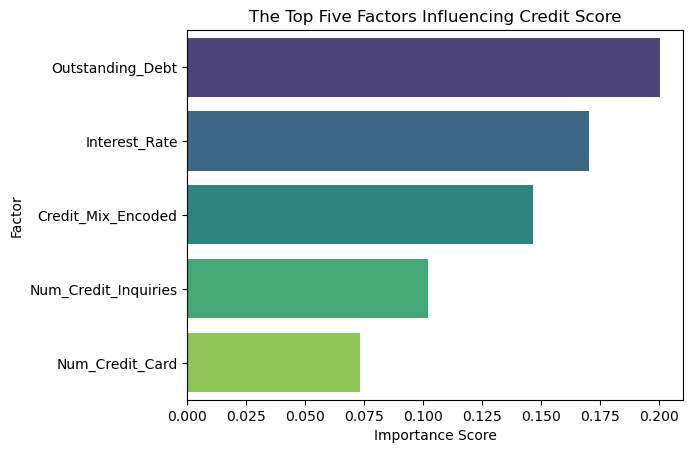

The most significant drivers of Credit Score are:
1. Outstanding_Debt (Impact: 0.20)
2. Interest_Rate (Impact: 0.17)
3. Credit_Mix_Encoded (Impact: 0.15)
4. Num_Credit_Inquiries (Impact: 0.10)
5. Num_Credit_Card (Impact: 0.07)


Sum of the importance of the top five features: 0.69
Importance shows how much of the model’s total decision-making comes from the top five features.
Note that this is not the same as variance explained, since target variable is categorical.


In [50]:
# Prepare data for Feature Importance (Numeric columns only)
X_features = df_clean.select_dtypes(include=np.number).drop(columns=['Credit_Score_Encoded'], errors='ignore')
y_feature = df_clean['Credit_Score_Encoded']

# Fit a RandomForestClassifier model to judge feature importance on credit score
from sklearn.ensemble import RandomForestClassifier
rf_stat = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_stat.fit(X_features, y_feature)

# Extract and plot feature importance
importances = pd.Series(rf_stat.feature_importances_, index=X_features.columns).sort_values(ascending=False).head(5)
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('The Top Five Factors Influencing Credit Score')
plt.xlabel('Importance Score')
plt.ylabel('Factor')
plt.show()

# Print the importance scores for the most significant factors
print("The most significant drivers of Credit Score are:")
for i, (col, score) in enumerate(importances.items()):
    print(f"{i+1}. {col} (Impact: {score:.2f})")
print("\n")
print(f"Sum of the importance of the top five features: {importances.sum():.2f}")

print("Importance shows how much of the model’s total decision-making comes from the top five features.")
print("Note that this is not the same as variance explained, since target variable is categorical.")

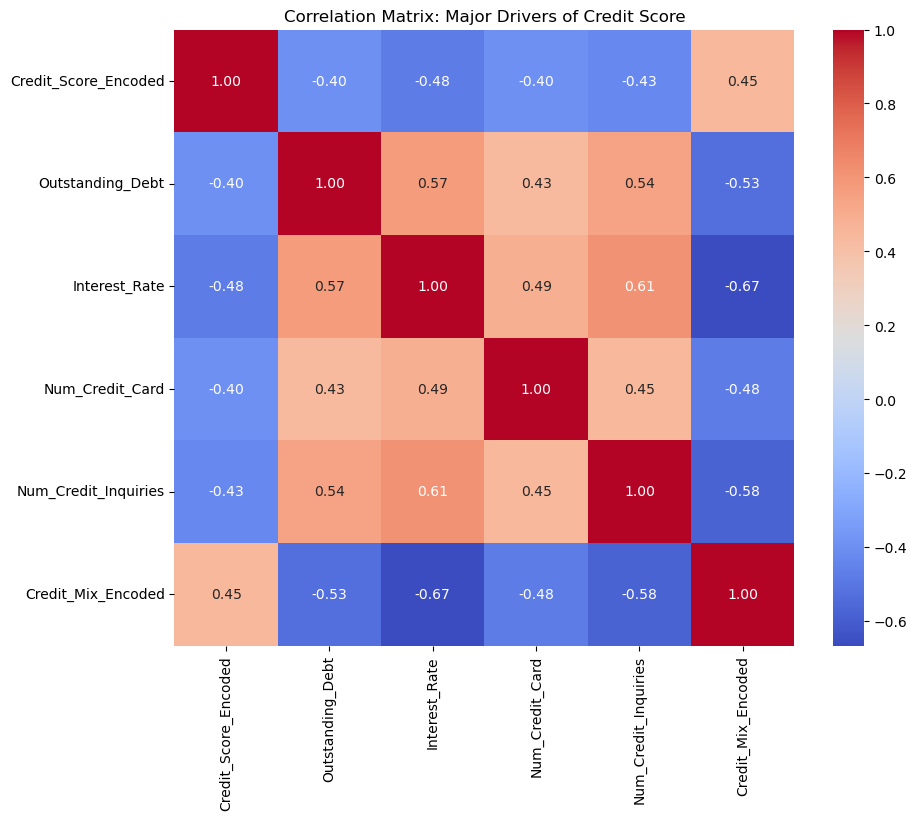

Credit Score is only positively correlated with credit mix, and negatively correlated with the other major factors.


In [51]:
# Correlation Matrix of most important features
most_important_features = ['Credit_Score_Encoded', 'Outstanding_Debt', 'Interest_Rate', 'Num_Credit_Card', 'Num_Credit_Inquiries', 'Credit_Mix_Encoded']

# Compute corr matrix
plt.figure(figsize=(10, 8))
corr = df_clean[most_important_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Major Drivers of Credit Score')
plt.show()

print("Credit Score is only positively correlated with credit mix, and negatively correlated with the other major factors.")

In [43]:
# Statistical analysis of a few of the most important drivers of credit score
from scipy import stats

# Testing ANOVA (Analysis of Variance)
# Does the average outstanding debt differ significantly across credit score categories?
# H0: Means are equal
# H1: Means are different

# Create groups of debt based on credit score category
debt_groups = [df_clean[df_clean['Credit_Score'] == i]['Outstanding_Debt'] for i in ['Poor', 'Standard', 'Good']]

# Perform ANOVA test
f_stat, p_val = stats.f_oneway(*debt_groups)
print(f"Test: ANOVA on Outstanding Debt")
print(f"F-Statistic: {f_stat:.2f} | P-Value: {p_val:.4e}")
if p_val < 0.05:
    print("We observe a significant difference. Debt levels fundamentally distinguish credit scores.")
    # Actionable Insights
    avg_debt_good = df_clean[df_clean['Credit_Score'] == 'Good']['Outstanding_Debt'].mean()
    avg_debt_poor = df_clean[df_clean['Credit_Score'] == 'Poor']['Outstanding_Debt'].mean()
    print(f"Recommendation: Focus risk assessment on Debt thresholds. 'Good' profiles average ${avg_debt_good:.0f}, while 'Poor' average ${avg_debt_poor:.0f}.")

# Testing Chi-Square Independence
# Is credit mix independent of credit score?

# Perform Chi-Square test
contingency = pd.crosstab(df_clean['Credit_Mix'], df_clean['Credit_Score'])
chi2, p_chi2, dof, ex = stats.chi2_contingency(contingency)
print(f"\nTest: Chi-Square on Credit Mix")
print(f"Chi2 Statistic: {chi2:.2f} | P-Value: {p_chi2:.4e}")
if p_chi2 < 0.05:
    print("We observe a significant association. Credit Mix is strongly linked to Credit Score.")
    print("Recommendation: Credit Mix should be an important aspect of any scoring rules. Applicants with diverse credit lines tend to cluster in higher score categories, so weighting this factor can improve risk segmentation.")

Test: ANOVA on Outstanding Debt
F-Statistic: 10050.15 | P-Value: 0.0000e+00
We observe a significant difference. Debt levels fundamentally distinguish credit scores.
Recommendation: Focus risk assessment on Debt thresholds. 'Good' profiles average $777, while 'Poor' average $1786.

Test: Chi-Square on Credit Mix
Chi2 Statistic: 30023.19 | P-Value: 0.0000e+00
We observe a significant association. Credit Mix is strongly linked to Credit Score.
Recommendation: Credit Mix should be an important aspect of any scoring rules. Applicants with diverse credit lines tend to cluster in higher score categories, so weighting this factor can improve risk segmentation.


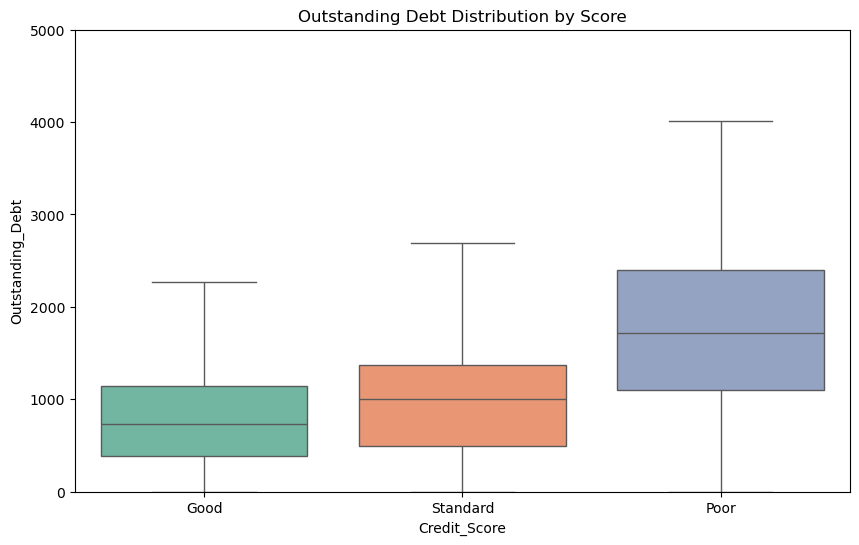

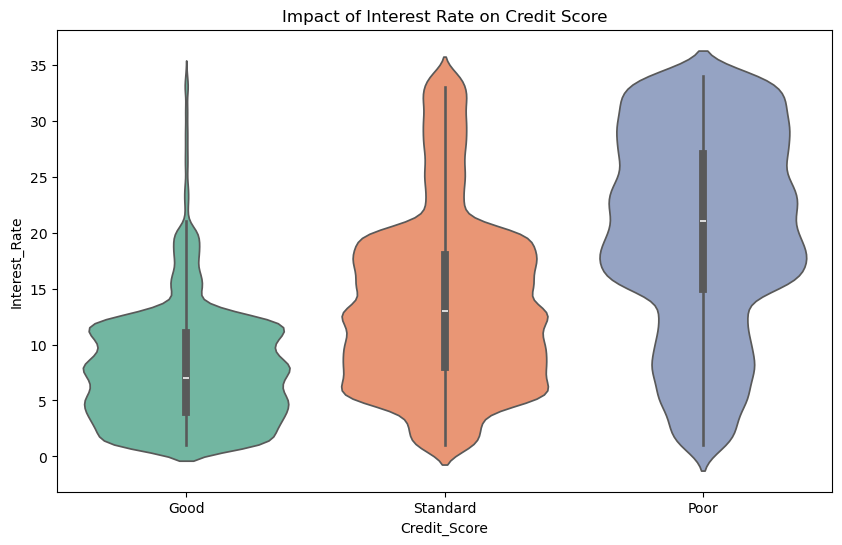

Debt distribution is more variable for those with a poor credit score, implying that there may be a 'debt cliff' after which outstanding debt doesn't impact credit score as much.
Although both 'Good' and 'Standard' credit score groups have similar outstanding debt distributions, those with a 'Standard' score have greater variance in interest rates.
It is very unlikely for someone with a 'Good' score to have a rate above 20%, yet for 'Standard' scorers this is more possible.
This is an easy way to differentiate between the two categories.


In [56]:
# Visualizing a few of the most important features

# Visualizing outstanding debt by credit score
plt.figure(figsize=(10, 6))
sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df_clean, order=['Good', 'Standard', 'Poor'], palette='Set2', showfliers=False)
plt.title('Outstanding Debt Distribution by Score')
plt.ylim(0, 5000)
plt.show()

# Visualizing distribution of interest rate on credit score
plt.figure(figsize=(10, 6))
sns.violinplot(x='Credit_Score', y='Interest_Rate', data=df_clean, order=['Good', 'Standard', 'Poor'], palette='Set2')
plt.title('Impact of Interest Rate on Credit Score')
plt.show()

# Insights
print("Debt distribution is more variable for those with a poor credit score, implying that there may be a 'debt cliff' after which outstanding debt doesn't impact credit score as much.")
print("Although both 'Good' and 'Standard' credit score groups have similar outstanding debt distributions, those with a 'Standard' score have greater variance in interest rates.")
print("It is very unlikely for someone with a 'Good' score to have a rate above 20%, yet for 'Standard' scorers this is more possible.")
print("This is an easy way to differentiate between the two categories.")

In [ ]:
# 5. Machine Learning Model
# In this section, we build an XGBoost model to classify credit scores from normalized data.


Training Shape: (80000, 31)
Testing Shape:  (20000, 31)


Training XGBoost Model...
Model Training Complete!


Model Accuracy: 69.56%


Classification Report:
              precision    recall  f1-score   support

        Poor       0.68      0.77      0.72      5799
    Standard       0.84      0.61      0.71     10635
        Good       0.52      0.82      0.63      3566

    accuracy                           0.70     20000
   macro avg       0.68      0.73      0.69     20000
weighted avg       0.74      0.70      0.70     20000



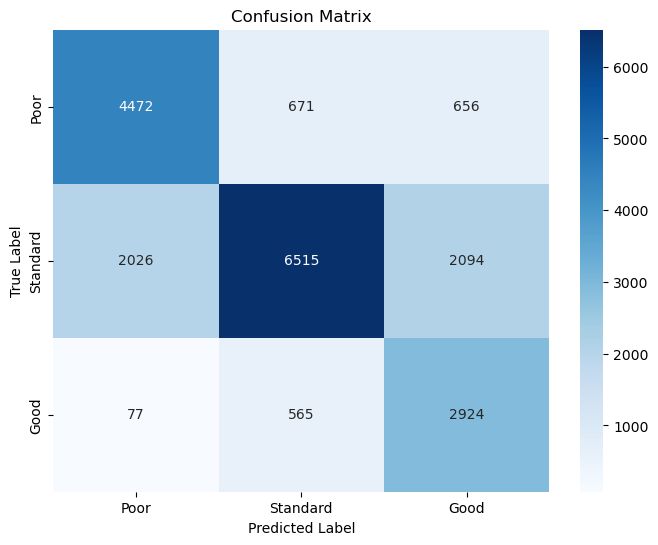

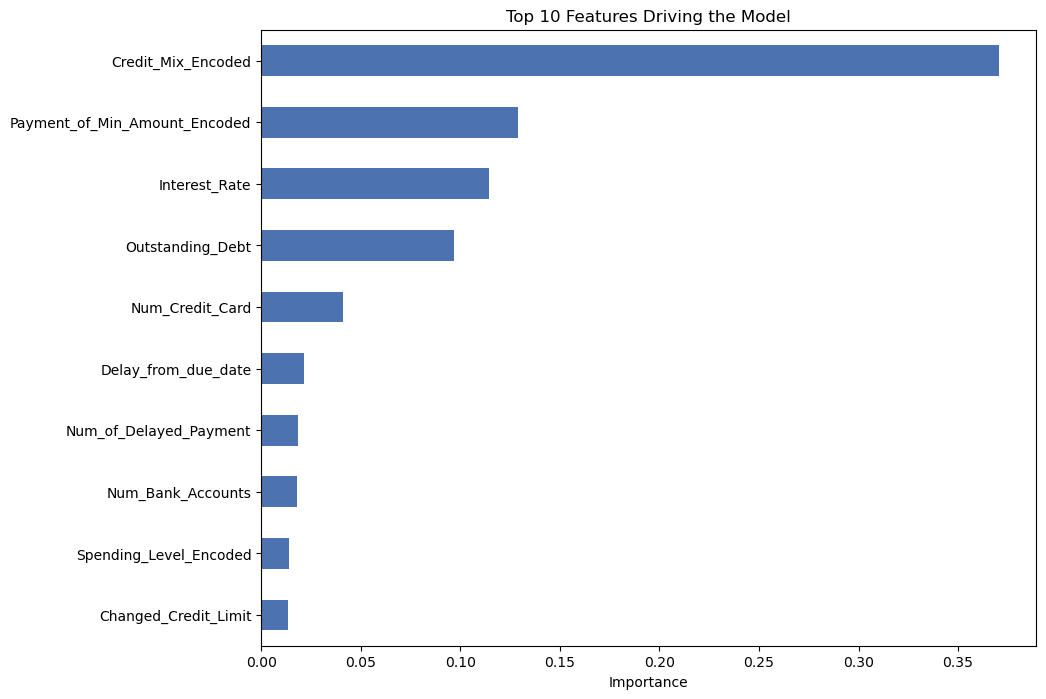

The model successfully predicts credit score classes based on demographic and financial data with ~70% accuracy.
The model often misinterprets Standard credit scores as Poor or Good scores, showing that the gap between the categories may not be as large as once thought.


Four out of five of the model's top features were the same as features identified prior, but with some notable exceptions.
The model places a higher emphasis on credit mix, and introduces Minimum Payment as a new feature previously unidentified by our statistical analysis.
This shows that credit analysts shouldn't just focus on credit mix but also individual performance on lines of credit.


In [66]:
# For this section, we will use df_ml, as it has already been normalized
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# We need to drop target variables as well as non-numeric string variables
# Here, 'Credit_Score' is the text target, and 'Credit_Score_Encoded' is the numeric target
cols_to_drop = ['Credit_Score', 'Credit_Score_Encoded', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount']

# Define Features (X) and Target (y)
X = df_ml.drop(columns=cols_to_drop)
y = df_ml['Credit_Score_Encoded']

# We perform a train/test split on the data: 80% Training / 20% Testing
# Using stratify=y ensures we keep the same balance of Good/Standard/Poor in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining Shape: {X_train.shape}")
print(f"Testing Shape:  {X_test.shape}")
print("\n")

# Calculate weights to help the model pay attention to minority classes (Good/Poor)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# XGBoost model training
print("Training XGBoost Model...")
# Define XGBoost parameters
model = XGBClassifier(
    objective='multi:softmax', 
    num_class=3, 
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

# Fit the model using the sample weights
model.fit(X_train, y_train, sample_weight=sample_weights)
print("Model Training Complete!")
print("\n")

# Evaluate the model on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\n")

# Calculate classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Poor', 'Standard', 'Good']))

# Calculate confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Poor', 'Standard', 'Good'], yticklabels=['Poor', 'Standard', 'Good'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate feature importance
plt.figure(figsize=(10, 8))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='#4c72b0')
plt.title('Top 10 Features Driving the Model')
plt.xlabel('Importance')
plt.show()

print("The model successfully predicts credit score classes based on demographic and financial data with ~70% accuracy.")
print("The model often misinterprets Standard credit scores as Poor or Good scores, showing that the gap between the categories may not be as large as once thought.")
print("\n")
print("Four out of five of the model's top features were the same as features identified prior, but with some notable exceptions.")
print("The model places a higher emphasis on credit mix, and introduces Minimum Payment as a new feature previously unidentified by our statistical analysis.")
print("This shows that credit analysts shouldn't just focus on credit mix but also individual performance on lines of credit.")